In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


time_index = pd.date_range("2026-02-17", periods=1440, freq="min")

battery_voltage = 28 + 0.2*np.sin(np.linspace(0, 20, 1440)) + np.random.normal(0, 0.05, 1440)
temperature = 20 + 2*np.sin(np.linspace(0, 10, 1440)) + np.random.normal(0, 0.3, 1440)
signal_strength = -80 + np.random.normal(0, 1, 1440)

df = pd.DataFrame({
    "battery_voltage": battery_voltage,
    "temperature": temperature,
    "signal_strength": signal_strength
}, index=time_index)

df.head()


,battery_voltage,temperature,signal_strength
2026-02-17 00:00:00,28.024836,20.198864,-82.238231
2026-02-17 00:01:00,27.995866,20.365941,-82.120700
2026-02-17 00:02:00,28.037943,20.082103,-80.606865
2026-02-17 00:03:00,28.084488,19.652643,-79.542313
2026-02-17 00:04:00,27.999405,20.175493,-82.747505


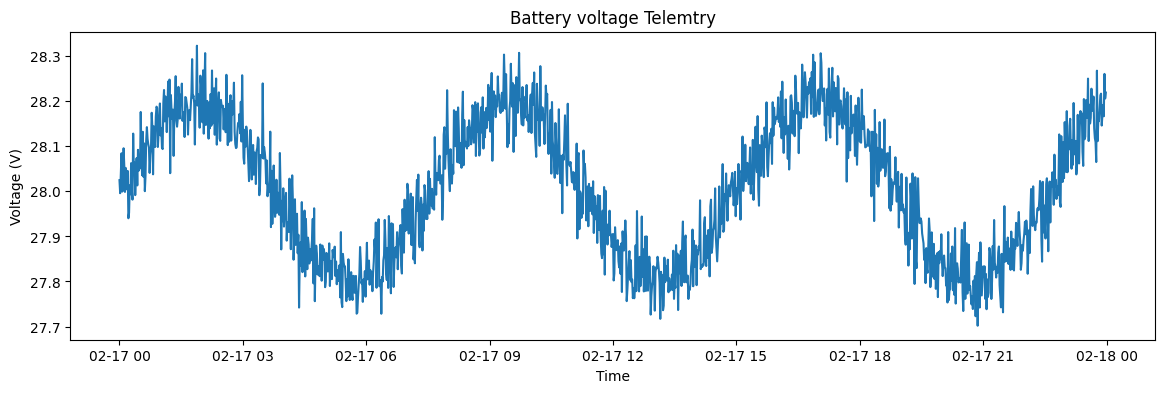

In [2]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df["battery_voltage"])
plt.title("Battery voltage Telemtry")
plt.xlabel("Time")
plt.ylabel("Voltage (V)")
plt.show()

In [3]:
# Inject anomaly + create ground-truth labels 

df_anomaly = df.copy()

# Battery drop anomaly: 12:00 - 12:20
start = "2026-02-17 12:00:00"
end   = "2026-02-17 12:20:00"

df_anomaly.loc[start:end, "battery_voltage"] -= 1.5

# Ground-truth label (for evaluation/presentation)
df_anomaly["true_anomaly"] = 0
df_anomaly.loc[start:end, "true_anomaly"] = 1

df_anomaly.loc[start:end].head()


,battery_voltage,temperature,signal_strength,true_anomaly
2026-02-17 12:00:00,26.405422,17.750697,-80.823935,1
2026-02-17 12:01:00,26.302213,18.162121,-80.719109,1
2026-02-17 12:02:00,26.318022,18.241763,-77.950188,1
2026-02-17 12:03:00,26.420328,18.438561,-79.999317,1
2026-02-17 12:04:00,26.389463,18.574990,-79.217870,1


In [4]:
#  Feature Scaling 

from sklearn.preprocessing import StandardScaler

features = ["battery_voltage", "temperature", "signal_strength"]

X = df_anomaly[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]


array([[ 0.15751376, -0.12845218, -2.14336599],
       [ 0.03972725, -0.00670895, -2.0288899 ],
       [ 0.21080732, -0.21353281, -0.55440401],
       [ 0.40005529, -0.52646668,  0.48247688],
       [ 0.05411663, -0.14548189, -2.63940206]])

In [5]:
#  Isolation Forest 

from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.015,   
    random_state=42
)

pred = model.fit_predict(X_scaled)

# sklearn: normal=1, anomaly=-1
df_anomaly["anomaly_flag"] = (pred == -1).astype(int)

df_anomaly["anomaly_flag"].sum()


np.int64(22)

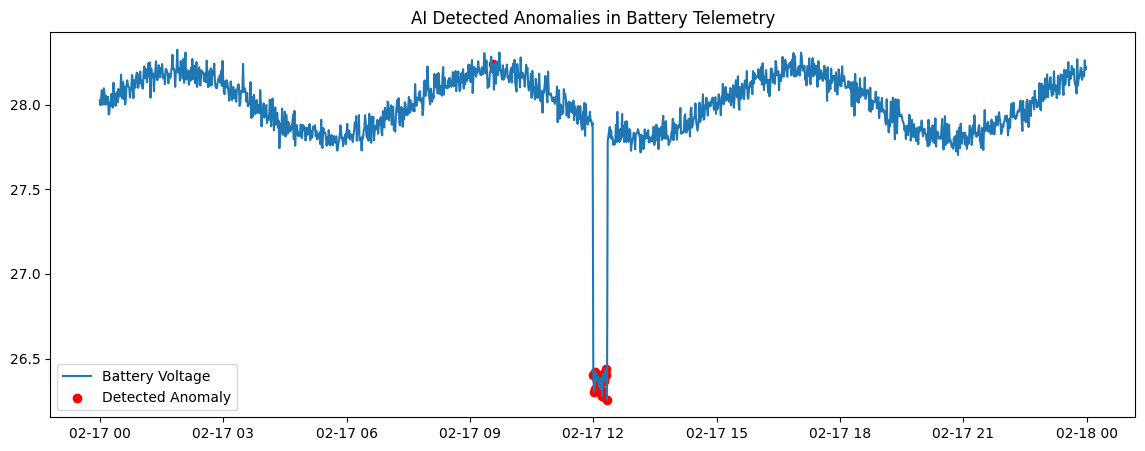

In [6]:
#  Visualizing Anomalies 
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# normal data
plt.plot(df_anomaly.index,
         df_anomaly["battery_voltage"],
         label="Battery Voltage")

# anomaly points
anomalies = df_anomaly[df_anomaly["anomaly_flag"] == 1]

plt.scatter(anomalies.index,
            anomalies["battery_voltage"],
            color="red",
            label="Detected Anomaly")

plt.legend()
plt.title("AI Detected Anomalies in Battery Telemetry")
plt.show()


In [7]:
#  One-Class SVM 

from sklearn.svm import OneClassSVM

svm_model = OneClassSVM(
    kernel="rbf",
    gamma="auto",
    nu=0.02  
)

svm_pred = svm_model.fit_predict(X_scaled)

# sklearn: normal=1, anomaly=-1
df_anomaly["svm_anomaly"] = (svm_pred == -1).astype(int)

df_anomaly["svm_anomaly"].sum()


np.int64(26)

In [8]:
print("Isolation Forest anomalies:",
      df_anomaly["anomaly_flag"].sum())

print("One-Class SVM anomalies:",
      df_anomaly["svm_anomaly"].sum())


Isolation Forest anomalies: 22
One-Class SVM anomalies: 26


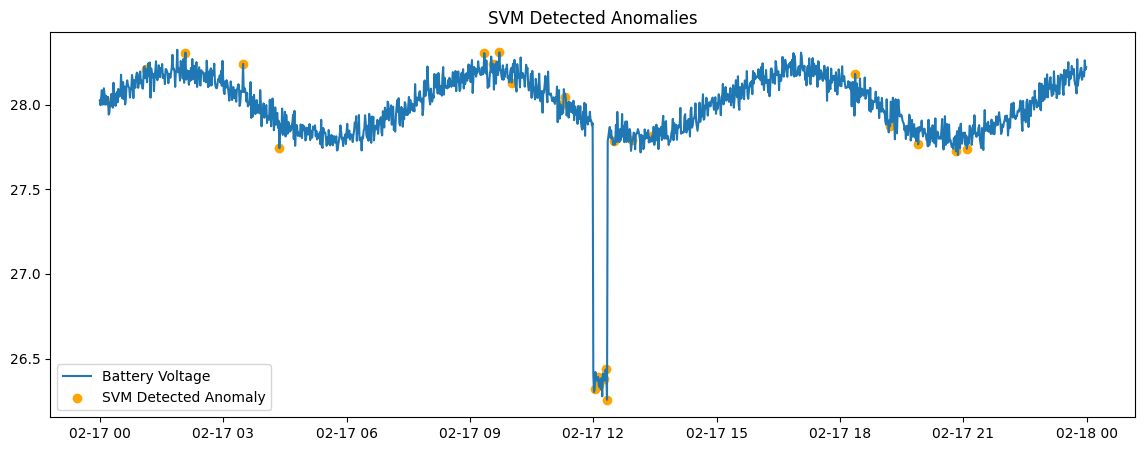

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))

# normal data
plt.plot(df_anomaly.index,
         df_anomaly["battery_voltage"],
         label="Battery Voltage")

# svm anomalies
svm_anomalies = df_anomaly[df_anomaly["svm_anomaly"] == 1]

plt.scatter(svm_anomalies.index,
            svm_anomalies["battery_voltage"],
            color="orange",
            label="SVM Detected Anomaly")

plt.legend()
plt.title("SVM Detected Anomalies")
plt.show()


In [10]:
#  Recreate anomaly injection 

np.random.seed(42)

anomaly_indices = np.random.choice(len(df_anomaly), size=20, replace=False)

df_anomaly["true_label"] = 0
df_anomaly.loc[df_anomaly.index[anomaly_indices], "true_label"] = 1

df_anomaly["true_label"].sum()


np.int64(20)

In [11]:
from sklearn.metrics import classification_report, confusion_matrix

print("Isolation Forest:")
print(confusion_matrix(df_anomaly["true_label"], df_anomaly["anomaly_flag"]))
print(classification_report(df_anomaly["true_label"], df_anomaly["anomaly_flag"]))


Isolation Forest:
[[1398   22]
 [  20    0]]
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1420
           1       0.00      0.00      0.00        20

    accuracy                           0.97      1440
   macro avg       0.49      0.49      0.49      1440
weighted avg       0.97      0.97      0.97      1440



In [12]:
#  Strong anomaly injection 

np.random.seed(42)

anomaly_indices = np.random.choice(len(df_anomaly), size=20, replace=False)


df_anomaly["true_label"] = 0


df_anomaly.loc[df_anomaly.index[anomaly_indices], "battery_voltage"] = 35
df_anomaly.loc[df_anomaly.index[anomaly_indices], "temperature"] = -50
df_anomaly.loc[df_anomaly.index[anomaly_indices], "signal_strength"] = -150

df_anomaly.loc[df_anomaly.index[anomaly_indices], "true_label"] = 1

df_anomaly["true_label"].sum()


np.int64(20)

In [13]:
from sklearn.preprocessing import StandardScaler

features = ["battery_voltage", "temperature", "signal_strength"]
X = df_anomaly[features].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=200,
    contamination=0.02,
    random_state=42
)

pred = model.fit_predict(X_scaled)

df_anomaly["anomaly_flag"] = (pred == -1).astype(int)

df_anomaly["anomaly_flag"].sum()


np.int64(29)

In [15]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(df_anomaly["true_label"], df_anomaly["anomaly_flag"]))
print(classification_report(df_anomaly["true_label"], df_anomaly["anomaly_flag"]))


[[1411    9]
 [   0   20]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1420
           1       0.69      1.00      0.82        20

    accuracy                           0.99      1440
   macro avg       0.84      1.00      0.91      1440
weighted avg       1.00      0.99      0.99      1440



In [16]:
#  Rule Based Detection (Library Limits) 

df_anomaly["rule_flag"] = 0

df_anomaly.loc[
    (df_anomaly["battery_voltage"] < 27.5) |
    (df_anomaly["battery_voltage"] > 29.0) |
    (df_anomaly["temperature"] < -20) |
    (df_anomaly["temperature"] > 60) |
    (df_anomaly["signal_strength"] < -120),
    "rule_flag"
] = 1

df_anomaly["rule_flag"].sum()


np.int64(41)

In [17]:
print("Rule Based System:")
print(confusion_matrix(df_anomaly["true_label"], df_anomaly["rule_flag"]))
print(classification_report(df_anomaly["true_label"], df_anomaly["rule_flag"]))


Rule Based System:
[[1399   21]
 [   0   20]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1420
           1       0.49      1.00      0.66        20

    accuracy                           0.99      1440
   macro avg       0.74      0.99      0.82      1440
weighted avg       0.99      0.99      0.99      1440



In [18]:
print("AI detected:", df_anomaly["anomaly_flag"].sum())
print("Rule detected:", df_anomaly["rule_flag"].sum())
print("True anomalies:", df_anomaly["true_label"].sum())


AI detected: 29
Rule detected: 41
True anomalies: 20
